# Imports

In [1471]:
# Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor 

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
import category_encoders as ce

from datetime import datetime
from IPython.display import display, HTML

from scipy.stats import norm

# Constants

In [1472]:

# Some useful constants
g_target_feature = "SalePrice"
g_random_state = 0
g_test_size = 0.2  # Proportion of the dataset to include in the test split
g_max_ohe_cardinality = 18  # Maximum unique values for one-hot encoding
g_df_scores = pd.DataFrame() #  DataFrame to store scores

## Category fields

In [1473]:
# Ordinal Columns
g_ord_cols = [
    "LandSlope", "OverallQual", "OverallCond", "ExterQual", "ExterCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "HeatingQC", "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"
]

g_ord_cat_maps = { 
    "LandSlope": {"Gtl": 1, "Mod": 2, "Sev": 3},
    "ExterQual": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "ExterCond": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "BsmtQual": {"Ex": 10, "Gd": 9, "TA": 8, "Fa": 7, "Po": 3, "NA": 0},
    "BsmtCond": {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1},
    "BsmtExposure": {"Gd": 5, "Av": 4, "Mn": 3, "No": 2, "NA": 0},
    "BsmtFinType1": {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, 
                     'NA':0},
    'BsmtFinType2': {'GLQ':6,'ALQ':5,'BLQ':4,'Rec':3,'LwQ':2,'Unf':1,'NA':0},
    'HeatingQC':{'Ex':5,'Gd':4,'TA':3,'Fa':2,'Po':1},
    'FireplaceQu':{'Ex':10,'Gd':9,'TA':8,'Fa':7,'Po':3,'NA':0},
    'GarageQual':{'Ex':10,'Gd':9,'TA':8,'Fa':7,'Po':3,'NA':0},
    'GarageCond':{'Ex':10,'Gd':9,'TA':8,'Fa':7,'Po':3,'NA':0},
    'PoolQC' : {'Ex' :10 , 'Gd' :9 , 'TA' :8 , 'Fa' :7 , 'Po' :3 , 'NA' :0}
}
g_feat_remove_01_01 = [
    "GarageYrBlt",  # Correlated with GarageCars
    "1stFlrSF",     # Correlated with TotalBsmtSF
    "TotRmsAbvGrd", # Correlated with GrLivArea
    "GarageArea"    # Correlated with GarageArea
]
g_feat_remove_01_02 = [    
    "LotFrontage", # Correlated with Lot area
    "YearRemodAdd", # Similar to Year Build
    "YearBuilt", # Will be replated by HouseAge -> Today - YearBuilt
    "BsmtFinSF1",
    "BsmtFinSF2", 
    "BsmtUnfSF", 
    "TotalBsmtSF", 
    "1stFlrSF", 
    "2ndFlrSF", 
    "WoodDeckSF", 
    "OpenPorchSF"
]

g_feat_remove_01 = g_feat_remove_01_02 + g_feat_remove_01_01

g_feat_remove_02 = ["YrSold", "MoSold", "MiscVal", "MiscFeature", "Fence", "ScreenPorch", "3SsnPorch", "EnclosedPorch", "WoodDeckSF", "GarageYrBlt", "Kitchen", "HalfBath", "KitchenAbvGr"]

# Functions

## Metrics functions

In [1474]:
# Metric functions 
def compute_rmse(y, y_pred):
    """Compute Root Mean Squared Error (RMSE)"""
    return root_mean_squared_error(y, y_pred)    
        
def compute_nrmse(y, y_pred):
    rmse = compute_rmse(y, y_pred)
    return rmse / np.mean(y) 
    
def compute_perc_nrmse(y, y_pred):
    return compute_nrmse(y, y_pred) * 100

def compute_metrics(y, y_pred):
    result = {}
    result["RMSE"] = compute_rmse(y, y_pred)
    result["NRMSE"] = compute_nrmse(y, y_pred)
    result["PERC_NRMSE"] = compute_perc_nrmse(y, y_pred)
    return result

def mean(vals):
    return vals.mean() if len(vals) > 0 else 0


## Printing functions

In [1475]:
# Show data functions
def println(ch="-", n=30):
    print(ch * n)
 
 
def show_values_summary(df):
    for col in df_low: 
        println()
        print(f"{col}: {df_data[col].nunique()} unique values") 
        println()
        print(df_data[col].value_counts())
        println(ch="_")
        
def print_title(title):
    println()
    print(title)
    println()

def display_score_metrics(scores):
    for index, score in enumerate(scores):
        print_title(f"Fold # {index}")
        print("RMSE:", -1 * score)
        
def df_tail(df, count=20):
    pd.set_option("display.max_columns", None)
    pd.set_option("display.max_rows", 100)
    pd.set_option("display.colheader_justify", "center")
    display(df.tail(count))

def show_global_scores():
    global g_df_scores
    display(g_df_scores)

def fmtnum(num):
    return "{:.5f}".format(num)

## Initial category processing

In [1476]:

def encode_categories(X, Y, X_test, Y_test, ord_cols, ord_cat_maps, target_feature):
    """
    Encodes categorical columns in the DataFrame.
    
    Args:
        df_data (pd.DataFrame): DataFrame containing the data.
        ord_cols (list): List of ordinal columns to encode.
        target_feature (str): Name of the target feature column.
    
    Returns:
        pd.DataFrame: DataFrame with encoded categorical columns.
    """
    # Extracting target category
    X = X.drop(labels=[target_feature, "Id"], axis=1, errors='ignore')
    X_test = X_test.drop(labels=[target_feature, "Id"], axis=1, errors='ignore')

    # Selecting Categorical columns from low cardinality categories
    df_ord = X[ord_cols]
    df_data_no_ord = X.drop(labels=ord_cols, axis=1, errors='ignore')

    df_ord_test = X_test[ord_cols]
    df_data_no_ord_test = X_test.drop(labels=ord_cols, axis=1, errors='ignore')

    # Extracting numeric and categorical columns with low and high cardinality
    num_cols, low_cols, hi_cols = extract_categorical_columns(df_data_no_ord, k=g_max_ohe_cardinality)

    subClassCol = "MSSubClass"
    # Training data
    df_cat = df_data_no_ord.drop(labels=num_cols, axis=1, errors='ignore').drop(labels=[subClassCol], axis=1, errors='ignore')
    df_num = X[num_cols].drop(labels=[subClassCol], axis=1, errors='ignore')
    
    #df_cat[subClassCol] = df_num.pop(subClassCol)
    df_hi_cat = df_cat[hi_cols]
    df_low_cat = df_cat.drop(labels=hi_cols, axis=1, errors='ignore')

    #Testing data
    df_cat_test = df_data_no_ord_test.drop(labels=num_cols, axis=1, errors='ignore').drop(labels=[subClassCol], axis=1, errors='ignore')
    df_num_test = X_test[num_cols].drop(labels=[subClassCol], axis=1, errors='ignore')

    #df_cat_test[subClassCol] = df_num_test.pop(subClassCol)
    df_hi_cat_test = df_cat_test[hi_cols]
    df_low_cat_test = df_cat_test.drop(labels=hi_cols, axis=1, errors='ignore')
    
    # One-hot encoding low cardinality categorical columns
    df_mscclass, df_mscclass_test = one_hot_encode(X[[subClassCol]], X_test[[subClassCol]])
    df_low_cat, df_low_cat_test = one_hot_encode(df_low_cat, df_low_cat_test)
    df_ord_cat, df_ord_cat_test = ordinal_encode(df_ord, df_ord_test, ord_cat_maps)
    
    # Target encoding high cardinality categorical columns
    df_target_cat, df_target_cat_test = target_encode(df_hi_cat, df_hi_cat_test, Y) 
    
    X = pd.concat([df_num, df_ord_cat, df_low_cat, df_target_cat, df_mscclass], axis=1)
    X_test = pd.concat([df_num_test, df_ord_cat_test, df_low_cat_test, df_target_cat_test, df_mscclass_test], axis=1)
    return X, X_test

## Evaluation functions

In [1477]:

def rndnum(n):
    return round(n, 5)
    
def clear_scores():
    global g_df_scores
    g_df_scores = pd.DataFrame()


# Evaluation functions
def eval_model(model, X, Y, X_test, Y_test, label="no_label"):
    """
    Evaluates a regression model using cross-validation and prints the RMSE and NRMSE.
    
    Args:
        model: The regression model to evaluate.
        X (pd.DataFrame): Features for training.
        Y (pd.Series): Target variable for training.
        X_test (pd.DataFrame): Features for testing.
        Y_test (pd.Series): Target variable for testing.
        cross_val (bool): Whether to perform cross-validation. Default is False.
    """
    global g_df_scores
    scores = cross_val_score(model, X, Y, cv=5, scoring="neg_root_mean_squared_error")
    scores = -scores  # Convert to positive RMSE values
        
    model.fit(X, Y)
    pred = model.predict(X_test)
    result = compute_metrics(Y_test, pred)
    new_row = {
        "date": datetime.now().strftime("%Y-%m-%d %H:%M"),
        "model": f"{model.__class__.__name__}",
        "run_label": label,
        "RMSE": rndnum(result["RMSE"]),
        "NRMSE": rndnum(result["NRMSE"]),
        "PERC_NRMSE": rndnum(result["PERC_NRMSE"]),
        "CV_MEAN": rndnum(mean(scores)),
        "CV_01": rndnum(scores[0]),
        "CV_02": rndnum(scores[1]),
        "CV_03": rndnum(scores[2]),
        "CV_04": rndnum(scores[3]),
        "CV_05": rndnum(scores[4]) 
    }

    df_new_row = pd.DataFrame([new_row])
    if len(g_df_scores) == 0:
        g_df_scores = df_new_row
    else:
        g_df_scores = pd.concat([g_df_scores, df_new_row], ignore_index=True)

def get_models():
    return [
        DummyRegressor(),
        LinearRegression(),
        DecisionTreeRegressor(),
        Ridge()
    ]

def eval_models(X, Y, X_test, Y_test, label=run_label, models=None):
    ev_models = models
    if ev_models is None:
        ev_models = get_models()
    for model in ev_models:
        eval_model(model, X, Y, X_test, Y_test, label=run_label)

## Creating custom features

In [1478]:
def create_custom_features(df, total_sf=True, house_age=True):
    df_new = df.copy()
    df_new["HouseAge"] = datetime.now().year -  df["YearBuilt"]
    df_new["TotalSF"] = df["GrLivArea"] + df["TotalBsmtSF"]
    
    return df_new

## Scaling functions

In [1479]:
def std_norm(df_X, df_X_test, columns=None):
    """
    Standard normalization of the DataFrame using StandardScaler.
    
    Args:
        df_X (pd.DataFrame): DataFrame to normalize.
        df_X_test (pd.DataFrame): Test DataFrame to normalize.
        columns (list, optional): List of columns to normalize. If None, all columns are normalized.
    
    Returns:
        pd.DataFrame: Normalized DataFrame.
    """
    scaler = StandardScaler()
    if columns is None:
        columns = df_X.columns
    
    df_X[columns] = scaler.fit_transform(df_X[columns])
    df_X_test[columns] = scaler.transform(df_X_test[columns])
    
    return df_X, df_X_test

def min_max_norm(df_X, df_X_test, columns=None):
    """
    Min-Max normalization of the DataFrame using MinMaxScaler.
    
    Args:
        df_X (pd.DataFrame): DataFrame to normalize.
        df_X_test (pd.DataFrame): Test DataFrame to normalize.
        columns (list, optional): List of columns to normalize. If None, all columns are normalized.
    
    Returns:
        pd.DataFrame: Normalized DataFrame.
    """
    scaler = MinMaxScaler()
    if columns is None:
        columns = df_X.columns
    
    df_X[columns] = scaler.fit_transform(df_X[columns])
    df_X_test[columns] = scaler.transform(df_X_test[columns])
    
    return df_X, df_X_test

def robust_norm(df_X, df_X_test, columns=None):
    """
    Robust normalization of the DataFrame using RobustScaler.
    
    Args:
        df_X (pd.DataFrame): DataFrame to normalize.
        df_X_test (pd.DataFrame): Test DataFrame to normalize.
        columns (list, optional): List of columns to normalize. If None, all columns are normalized.
    
    Returns:
        pd.DataFrame: Normalized DataFrame.
    """
    scaler = RobustScaler()
    if columns is None:
        columns = df_X.columns
    
    df_X[columns] = scaler.fit_transform(df_X[columns])
    df_X_test[columns] = scaler.transform(df_X_test[columns])
    
    return df_X, df_X_test

def scale_numeric(df_train, df_test):
    num_cols_final = df_train.select_dtypes(include=[np.number]).columns
    scaler = StandardScaler()
    df_train[num_cols_final] = scaler.fit_transform(df_train[num_cols_final])
    df_test[num_cols_final] = scaler.transform(df_test[num_cols_final])
    return df_train, df_test


## Transforming functions

In [1480]:
def transform_log1(df_X, df_X_test, columns=None):
    """
    Applies log1p transformation to the specified columns in the DataFrame.
    
    Args:
        df_X (pd.DataFrame): DataFrame to transform.
        df_X_test (pd.DataFrame): Test DataFrame to transform.
        columns (list, optional): List of columns to transform. If None, all columns are transformed.
    
    Returns: 
        A data frame where log1 was applied in 'columns' 
    """
    tran_X = df_X.copy()
    tran_X_test = df_X_test.copy()
    for col in columns:
        tran_X[col] = np.log1p(X[col])
        tran_X_test[col] = np.log1p(X_test[col])
    
    return tran_X, tran_X_test


## Util functions

In [1481]:
# Util functions
def extract_categorical_columns(df, k):
    """
    Extracts numeric and categorical columns from a DataFrame, and splits categorical columns into low and high cardinality based on a threshold k.
    
    Args:
        df (pd.DataFrame): Input dataframe.
        k (int): Threshold for maximum unique values to consider a column low cardinality.
    
    Returns:
        num_cols (Index): Numeric columns.
        low_cardi (Index): Categorical columns with fewer than k unique values.
        high_cardi (Index): Categorical columns with k or more unique values.
    """
    # Not including category type because the data is loaded from a csv and 
    # the columns are not set to category type by default.
    cat_cols = df.select_dtypes(include=["object"]).columns
    num_cols = df.select_dtypes(include=[np.number]).columns

    low_cardi = [col for col in cat_cols if df[col].nunique() < k] 
    high_cardi = [col for col in cat_cols if df[col].nunique() >= k]
    return num_cols, low_cardi, high_cardi

def split_data(df, test_size=g_test_size, random_state=g_random_state):
    df_train, df_test = train_test_split(
        df, 
        test_size=test_size, 
        random_state=random_state, 
        shuffle=True
    )
    Y = df_train.pop(g_target_feature)
    X = df_train
    
    Y_test = df_test.pop(g_target_feature)
    X_test = df_test   

    return X, Y, X_test, Y_test


## Enconding functions

In [1482]:
# Encoding functions
def one_hot_encode(df_X, df_X_test):
    """
    One-hot encodes all columns in the given DataFrame using sklearn's OneHotEncoder.
    
    Args:
        df (pd.DataFrame): DataFrame containing only categorical columns to encode.
    
    Returns:
        pd.DataFrame: One-hot encoded DataFrame with new binary columns for each category.
    """
    # One-hot encode only low cardinality
    ohe = OneHotEncoder(sparse_output=False, drop="first", handle_unknown="infrequent_if_exist")  # drop first to avoid dummy trap
    ohe.fit(df_X)
    # Get feature names from encoder
    feature_names = ohe.get_feature_names_out(df_X.columns)

    # Convert back to DataFrames
    df_X_enc = pd.DataFrame(ohe.transform(df_X), columns=feature_names, index=df_X.index)
    df_X_test_enc = pd.DataFrame(ohe.transform(df_X_test), columns=feature_names, index=df_X_test.index)
    return df_X_enc, df_X_test_enc 


def ordinal_encode(df_X, df_X_test, ord_cat_maps):
    """
    Ordinally encodes specified columns in a DataFrame using provided category-to-integer mappings.
    
    Args:
        df (pd.DataFrame): DataFrame containing columns to encode.
        ord_cat_maps (dict): Dictionary mapping column names to their category-to-integer mappings.
    
    Returns:
        pd.DataFrame: DataFrame with ordinally encoded columns, prefixed with 'enc_'.
    """ 
    df_new = pd.DataFrame()
    df_new_test = pd.DataFrame()
    cols = df.columns
    for col in cols:
        if col in ord_cat_maps:
            df_new["enc_" + col] = df_X[col].apply(lambda x: my_map(x, col, ord_cat_maps))
            df_new_test["enc_" + col] = df_X_test[col].apply(lambda x: my_map(x, col, ord_cat_maps))

    return df_new, df_new_test

def target_encode(df_X, df_X_test, Y): 
    df_X_new = df_X.copy()
    df_X_test_new = df_X_test.copy()
    encoder = ce.TargetEncoder(cols=df_X.columns, smoothing=10).fit(df_X, Y)

    df_X_new = encoder.transform(df_X)
    df_X_new_test = encoder.transform(df_X_test)
    return df_X_new, df_X_new_test


def my_map(x, col, ord_cat_maps):
    values = ord_cat_maps.get(col, -1)
    val = values.get(x, -1)  # Default to -1 if x is not in the mapping
    if pd.isna(x):
        val = -1
    return val

## Fixing Nans

In [1483]:
def nans_simple_fix(df_ori, strategy="constant", fill_value_num=0, fill_value_str="None"):
    
    df = df_ori.copy() 
    imp_num = SimpleImputer(missing_values=np.nan, strategy=strategy, fill_value=fill_value_num)
    
    imp_str = SimpleImputer(missing_values=np.nan, strategy=strategy, fill_value=fill_value_str)

    # Separate numeric/categorical
    num_cols = df.select_dtypes(include=[np.number]).columns.drop('SalePrice', errors='ignore')
    cat_cols = df.select_dtypes(include=['object']).columns

    # Re-run feature engineering, splitting, and scaling
    df[num_cols] = imp_num.fit_transform(df[num_cols]) 
    df[cat_cols] = imp_str.fit_transform(df[cat_cols]) 

    return df 

def nans_general_fix(df_ori):
    df = df_ori.copy() 
    # Separate numeric/categorical
    num_cols = df.select_dtypes(include=[np.number]).columns.drop('SalePrice', errors='ignore')
    cat_cols = df.select_dtypes(include=['object']).columns
    
    # Impute missing (median for num, most_frequent for cat; special for high-missing cats)
    for col in cat_cols:
        if df[col].isnull().sum() / len(df) > 0.5:  # High missing: 'None'
            df[col] = df[col].fillna('None')
        else:
            df[col] = df[col].fillna(df[col].mode()[0])
    
    # Re-run feature engineering, splitting, and scaling
    num_imputer = SimpleImputer(strategy='median')
    df[num_cols] = num_imputer.fit_transform(df[num_cols]) 
    return df

## Ploting Functions

In [1484]:
def show_distribution(data, columns=[]):
    plot_count = len(columns)
    if plot_count == 0:
        return
    
    # Create subplots
    fig, axes = plt.subplots(1, plot_count, figsize=(18, 5), squeeze=False)

    for ax, col in zip(axes, columns):
        kde = gaussian_kde(data[col])
        mu, sigma = np.mean(data[col]), np.std(data[col])
        x_vals = np.linspace(data[col].min(), data[col].max(), 200)
        
        ax[0].plot(x_vals, kde(x_vals), color="red", lw=2)
        ax[0].plot(x_vals, norm.pdf(x_vals, mu, sigma), color="yellow", lw=2)
        ax[0].hist(data[col], bins=30, color="skyblue", alpha=0.7, edgecolor="black", density=True)
        ax[0].set_title(f"Distribution of {col}")
        ax[0].set_xlabel(col)
        ax[0].set_ylabel("Frequency") 
    # Show plot
    plt.show()

def plot_scores():
    models_abrev = {
        "DummyRegressor": "DuRe",
        "LinearRegression": "LiRe",
        "DecisionTreeRegressor": "DeTr",
        "Ridge": "Ri"
    }
    
    df = g_df_scores.copy()
    # Combine model + run label for easier plotting
    df["model"] = df["model"].replace(models_abrev)
    
    df["model_run"] = df["model"].astype(str) + "\n(" + df["run_label"].astype(str) + ")"

        # Assign a unique color per model
    unique_models = df["model"].unique()
    colors = plt.cm.tab10(range(len(unique_models)))  # 10 distinct colors
    color_map = dict(zip(unique_models, colors))
    
    # Map the colors to each row
    df["color"] = df["model"].map(color_map)
    
    # Set figure and subplots
    fig, axes = plt.subplots(2, 1, figsize=(14, 5))
    
    # --- Bar chart for RMSE ---
    bars0 = axes[0].bar(df["model_run"], df["RMSE"], color=df["color"])
    axes[0].set_title("Test set (RMSE)")
    axes[0].set_ylabel("RMSE")
    axes[0].bar_label(bars0, fmt="%.0f", rotation=90, padding=3)
    #axes[0].tick_params(axis="x", rotation=45, ha="right")
    
    # --- Bar chart for CV_MEAN ---
    bars1 = axes[1].bar(df["model_run"], df["CV_MEAN"], color=df["color"])
    axes[1].set_title("Cross validation (CV_MEAN)")
    axes[1].set_ylabel("CV_MEAN")
    axes[1].bar_label(bars1, fmt="%.0f", rotation=90, padding=3)
    #axes[1].tick_params(axis="x", rotation=45, ha="right")
    
    plt.tight_layout()
    plt.show()


# Data loading

In [1485]:
# Loading data and split datasets
#df_submit = pd.read_csv("./data/test.csv")
df_data = pd.read_csv("./data/train.csv")


# Baseline Evaluation

/home/javi/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [8, 12, 20, 25] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Train dataset shape: (1168, 198)
Test dataset shape: (292, 198)


/home/javi/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [8, 12, 20, 25] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Train dataset shape: (1168, 195)
Test dataset shape: (292, 195)


,date,model,run_label,RMSE,NRMSE,PERC_NRMSE,CV_MEAN,CV_01,CV_02,CV_03,CV_04,CV_05
0,2025-10-06 20:16,DummyRegressor,base,83103.34066,0.45820,45.81969,78323.22731,77159.68753,80422.26927,82584.43558,84399.53503,67050.20913
1,2025-10-06 20:16,LinearRegression,base,55022.72736,0.30337,30.33722,32531.31142,30419.38902,40851.50832,31830.14590,34241.79923,25313.71464
2,2025-10-06 20:16,DecisionTreeRegressor,base,42331.39239,0.23340,23.33975,40258.50096,35507.48915,50600.59024,40954.29838,44797.57764,29432.54939
3,2025-10-06 20:16,Ridge,base,49640.30581,0.27370,27.36958,30527.66756,28026.60147,39954.09402,26703.70248,33927.26625,24026.67357
4,2025-10-06 20:16,DummyRegressor,base_1,83103.34066,0.45820,45.81969,78323.22731,77159.68753,80422.26927,82584.43558,84399.53503,67050.20913
5,2025-10-06 20:16,LinearRegression,base_1,55069.57474,0.30363,30.36305,32127.71336,28136.33850,40596.64340,32395.79908,34574.04053,24935.74531
6,2025-10-06 20:16,DecisionTreeRegressor,base_1,44517.64931,0.24545,24.54516,43653.87629,39342.28391,53036.30996,43964.45345,43365.76330,38560.57083
7,2025-10-06 20:16,Ridge,base_1,49394.37513,0.27234,27.23398,30586.42812,27865.16814,39595.89904,27412.15661,34218.71239,23840.20440


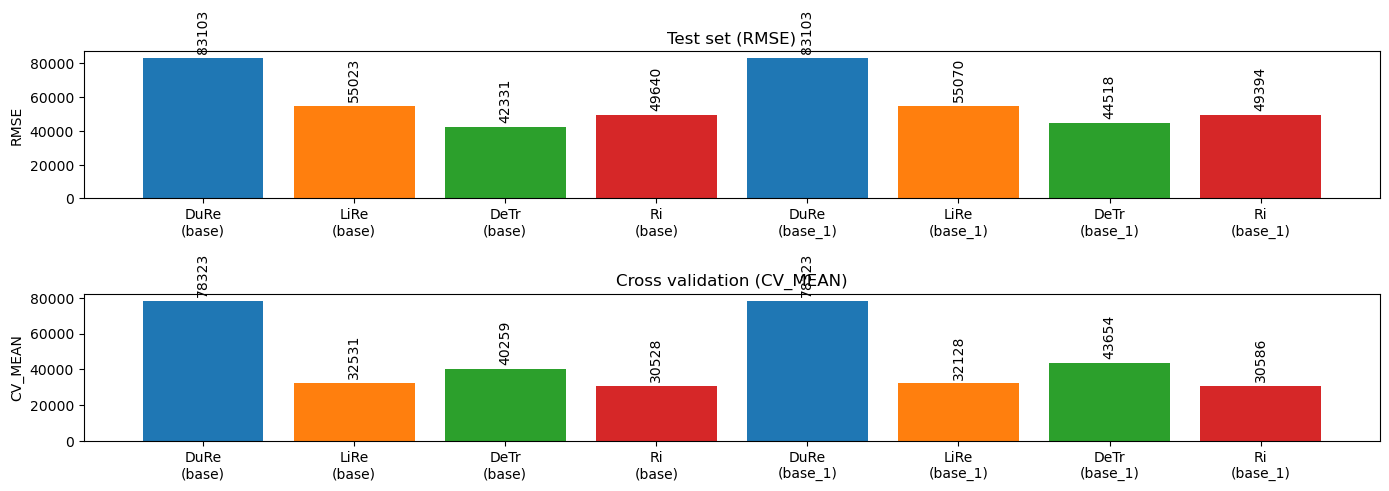

In [1486]:

# Before starting the analysis, let's setup a baseline performance
# Testing some simple models
run_label="base"
df_ready = nans_simple_fix(df_data)

# Split in train and test datasets
X, Y, X_test, Y_test = split_data(df_ready)
X, X_test = encode_categories(X, Y, X_test, Y_test, g_ord_cols, g_ord_cat_maps, g_target_feature) 

print("Train dataset shape:", X.shape)
print("Test dataset shape:", X_test.shape)

eval_models(X, Y, X_test, Y_test, label=run_label)

run_label="base_1"
df_ready1 = nans_general_fix(df_data)

X, Y, X_test, Y_test = split_data(df_ready1)
X, X_test = encode_categories(X, Y, X_test, Y_test, g_ord_cols, g_ord_cat_maps, g_target_feature) 

print("Train dataset shape:", X.shape)
print("Test dataset shape:", X_test.shape)

eval_models(X, Y, X_test, Y_test, label=run_label)

show_global_scores()
plot_scores()


# Exploratory Data Analysis (EDA)

## Some global variables for this section

In [1275]:
g_cols_remove = set() # Columns to remove from dataset

In [1276]:
#df_data.info()
null_columns = df_ready.columns[df_ready.isna().any()]
print("Columns with null values:", null_columns.tolist())

df_ready.describe(include="all")


Columns with null values: []


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460,1460.000000,1460.000000,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460.000000,1460.000000,1460.000000,1460.000000,1460,1460,1460,1460,1460,1460.000000,1460,1460,1460,1460,1460,1460,1460,1460.000000,1460,1460.000000,1460.000000,1460.000000,1460,1460,1460,1460,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460,1460.000000,1460,1460.000000,1460,1460,1460.000000,1460,1460.000000,1460.000000,1460,1460,1460,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460,1460,1460,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,3,4,4,2,5,3,25,9,8,5,8,NaN,NaN,NaN,NaN,6,8,15,16,4,NaN,4,5,6,5,5,5,7,NaN,7,NaN,NaN,NaN,6,5,2,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,7,NaN,6,7,NaN,4,NaN,NaN,6,6,3,NaN,NaN,NaN,NaN,NaN,NaN,4,5,5,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,NaN,NaN,NaN,NaN,Gable,CompShg,VinylSd,VinylSd,None,NaN,TA,TA,PConc,TA,TA,No,Unf,NaN,Unf,NaN,NaN,NaN,GasA,Ex,Y,SBrkr,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TA,NaN,Typ,NaN,None,Attchd,NaN,Unf,NaN,NaN,TA,TA,Y,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,1369,925,1311,1459,1052,1382,225,1260,1445,1220,726,NaN,NaN,NaN,NaN,1141,1434,515,504,872,NaN,906,1282,647,649,1311,953,430,NaN,1256,NaN,NaN,NaN,1428,741,1365,1334,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,735,NaN,1360,NaN,690,870,NaN,605,NaN,NaN,1311,1326,1340,NaN,NaN,NaN,NaN,NaN,NaN,1453,1179,1406,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,57.623288,10516.828082,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.099315,5.575342,1971.267808,1984.865753,NaN,NaN,NaN,NaN,NaN,103.117123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,443.639726,NaN,46.549315,567.240411,1057.429452,NaN,NaN,NaN,NaN,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,NaN,6.517808,NaN,0.613014,NaN,NaN,1868.739726,NaN,1.767123,472.980137,NaN,NaN,NaN,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,34.664304,9981.264932,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.382997,1.112799,30.202904,20.645407,NaN,NaN,NaN,NaN,NaN,180.731373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,456.098091,NaN,161.319273,441.866955,438.705324,NaN,NaN,NaN,NaN,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,NaN,1.625393,NaN,0.644666,NaN,NaN,453.697295,NaN,0.747315,213.804841,NaN,NaN,NaN,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,0.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1872.000000,1950.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,2.000000,NaN,0.000000,NaN

## Functions

### Correlation

In [1277]:
# Correlation between features and target. Here we are trying to know which features are releant to predict the target variable
# Correlation near 0 could mean that the feature is not relevant to predict the target variable or that it has a non linear relationship with it 
def get_high_corr_feat(df, threshold=0.8):
    # Correlation matrix between beatures
    corr_matrix = df.drop(labels=["Id", "SalePrice"], axis=1).corr(numeric_only=True)
    # Get pairs of features with correlation > 0.8
    high_corr = np.where(np.abs(corr_matrix) > 0.8)

    # Select only pairs of features with correlation > 0.8 and not the same feature
    high_corr_pairs = [(corr_matrix.index[row], corr_matrix.columns[col], corr_matrix.iloc[row, col])
                   for row, col in zip(*high_corr) if corr_matrix.index[row] != corr_matrix.columns[col]]
    return high_corr_pairs

def print_high_corr_feat(df, threshold=0.8):
    high_corr_pairs = get_high_corr_feat(df, threshold)
    if not high_corr_pairs:
        print("No highly correlated features found.")
        return
    
    print(f"Highly correlated feature pairs (corr > {threshold}):")
    for feat1, feat2, corr_val in high_corr_pairs:
        print(f"{feat1} - {feat2}: {corr_val:.2f}")
        

### Removing columns function

In [1291]:
# Based in previous corr analysis update columns to remove
def remove_unused_features(df, cols):
    """
    Remove specified columns from the DataFrame.
    
    Args:
        df (pd.DataFrame): DataFrame from which to remove columns.
        cols (list): List of column names to remove.
    
    Returns:
        pd.DataFrame: DataFrame with specified columns removed.
    """

    print("Cols to remove:", cols)
    return df.drop(labels=cols, axis=1, errors='ignore')


## Correlation inspection

<Axes: >

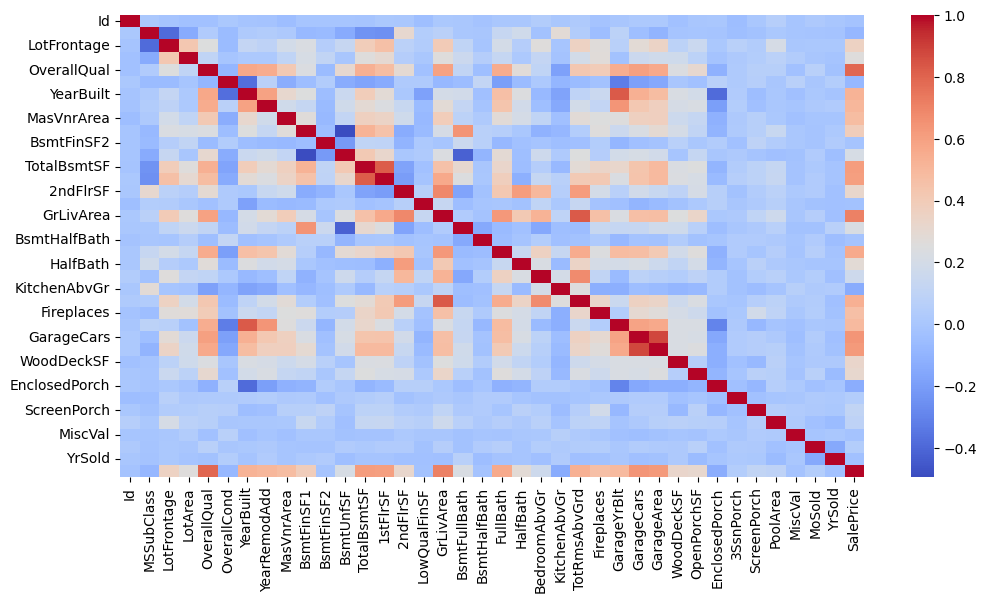

In [1292]:
# Correlation between featues. It is intended to spot redundant features
plt.figure(figsize=(12, 6))
sns.heatmap(df_data.corr(numeric_only=True), cmap="coolwarm", annot=False)

In [1280]:
print_high_corr_feat(df_data, threshold=0.8)


Highly correlated feature pairs (corr > 0.8):
YearBuilt - GarageYrBlt: 0.83
TotalBsmtSF - 1stFlrSF: 0.82
1stFlrSF - TotalBsmtSF: 0.82
GrLivArea - TotRmsAbvGrd: 0.83
TotRmsAbvGrd - GrLivArea: 0.83
GarageYrBlt - YearBuilt: 0.83
GarageCars - GarageArea: 0.88
GarageArea - GarageCars: 0.88


**From the output above, we can see that some candidates for removal are:**
- GarageYrBlt
- 1sFlrSF
- TotRmsAbvGrd
- GarageCars

### Evaluate

df_data["Fence"]
cols = ["YrSold", "MoSold", "MiscVal", "MiscFeature", "Fence", "ScreenPorch", "3SsnPorch", "EnclosedPorch", "WoodDeckSF", "GarageYrBlt", "Kitchen", "HalfBath", "KitchenAbvGr"]
cols = ["YrSold", "MoSold", "MiscVal", "ScreenPorch", "3SsnPorch", "EnclosedPorch", "WoodDeckSF", "GarageYrBlt", "HalfBath", "KitchenAbvGr"]
df_comp = df_ready[cols]
plt.figure(figsize=(12, 6))
sns.heatmap(df_comp.corr(numeric_only=True), cmap="coolwarm", annot=False)
#df_new_c.corr

In [1285]:

# Checking resuls when removing columns
df = remove_unused_features(df_ready, g_cols_remove) 

X, Y, X_test, Y_test = split_data(df)
eval_model(LinearRegression(), X, Y, X_test, Y_test, label="first_remove")
eval_model(DecisionTreeRegressor(), X, Y, X_test, Y_test, label="first_remove")
eval_model(Ridge(), X, Y, X_test, Y_test, label=run_label)

show_global_scores()


Cols to remove: {'GarageArea', 'GarageYrBlt', '1stFlrSF', 'TotRmsAbvGrd'}


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/home/javi/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/javi/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/javi/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklearn/linear_model/_base.py", line 618, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "/home/javi/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklea

### Playing with features / Creating ratio features

#### Remove Feat 01

In [1293]:
run_label = "remove_feat_01"
X_eval_01 = remove_unused_features(df_ready, g_feat_remove_01)

# Split in train and test datasets
X, Y, X_test, Y_test = split_data(X_eval_01)

print("Train dataset shape:", X.shape)
print("Test dataset shape:", X_test.shape)

eval_model(LinearRegression(), X, Y, X_test, Y_test, label=run_label)
eval_model(DecisionTreeRegressor(), X, Y, X_test, Y_test, label=run_label)
eval_model(Ridge(), X, Y, X_test, Y_test, label=run_label)


#show_global_scores()

Cols to remove: ['LotFrontage', 'YearRemodAdd', 'YearBuilt', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'WoodDeckSF', 'OpenPorchSF', 'GarageYrBlt', '1stFlrSF', 'TotRmsAbvGrd', 'GarageArea']
Train dataset shape: (1168, 66)
Test dataset shape: (292, 66)


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/home/javi/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/javi/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/javi/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklearn/linear_model/_base.py", line 618, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "/home/javi/miniconda3/envs/rl-gym/lib/python3.12/site-packages/sklea

#### New Feat 01

In [ ]:
run_label = "new_feat_01"
X_eval_02 = create_custom_features(df_ready)
X_eval_02 = remove_unused_features(X_eval_02, g_cols_remove)

# Split in train and test datasets
X, Y, X_test, Y_test = split_data(X_eval_02)

eval_model(LinearRegression(), X, Y, X_test, Y_test, label=run_label)
eval_model(DecisionTreeRegressor(), X, Y, X_test, Y_test, label=run_label)
eval_model(Ridge(), X, Y, X_test, Y_test, label=run_label)

show_global_scores()


#### Remove Feat 02

In [ ]:
run_label = "remove_feat_02"
cols_remove_02 = ["YrSold", "MoSold", "MiscVal", "MiscFeature", "Fence", "ScreenPorch", "3SsnPorch", "EnclosedPorch", "WoodDeckSF", "GarageYrBlt", "Kitchen", "HalfBath", "KitchenAbvGr"]
#print(g_cols_remove)
g_cols_remove.update(cols_remove_02)

X_eval_02 = create_custom_features(df_ready)
#X_eval_02 = df_ready.copy()
X_eval_02 = remove_unused_features(X_eval_02, g_feat_remove_01)
X_eval_02 = remove_unused_features(X_eval_02, g_feat_remove_02)
# Split in train and test datasets
X, Y, X_test, Y_test = split_data(X_eval_02)
eval_model(LinearRegression(), X, Y, X_test, Y_test, label=run_label)
eval_model(DecisionTreeRegressor(), X, Y, X_test, Y_test, label=run_label)
eval_model(Ridge(), X, Y, X_test, Y_test, label=run_label)

show_global_scores()


#### Scaling Robuts, Standard, MinMax

In [ ]:
run_label="scaling_robust"


df_scal = create_custom_features(df_ready)
df_scal = remove_unused_features(df_scal, g_cols_remove)

# Split in train and test datasets
X, Y, X_test, Y_test = split_data(df_scal)
X, X_test = robust_norm(X, X_test, columns=["TotalSF", "HouseAge"])
# X
eval_model(LinearRegression(), X, Y, X_test, Y_test, label=run_label)
eval_model(DecisionTreeRegressor(), X, Y, X_test, Y_test, label=run_label)
eval_model(Ridge(), X, Y, X_test, Y_test, label=run_label)
show_global_scores()

#### Transform Log1p

In [ ]:
run_label="transforming_log1"


df_scal = create_custom_features(df_ready)
df_scal = remove_unused_features(df_scal, g_cols_remove)

# Split in train and test datasets
X, Y, X_test, Y_test = split_data(df_scal)
X, X_test = transform_log1(X, X_test, columns=["TotalSF", "HouseAge"])

# X
eval_model(LinearRegression(), X, Y, X_test, Y_test, label=run_label)
eval_model(DecisionTreeRegressor(), X, Y, X_test, Y_test, label=run_label)
eval_model(Ridge(), X, Y, X_test, Y_test, label=run_label)
show_global_scores()

In [ ]:
# Testing normalization
df_scal = create_custom_features(df_ready)
df_scal, test = robust_norm(df_scal, df_scal, columns=["TotalSF", "HouseAge"])

#df_scal["TotalSF"].describe()
df_scal["HouseAge"].describe()





In [ ]:
# cols = ["YrSold", "MoSold", "MiscVal", "MiscFeature", "Fence", "ScreenPorch", "3SsnPorch", "EnclosedPorch", "WoodDeckSF", "GarageYrBlt", "Kitchen", "HalfBath", "KitchenAbvGr"]

# #df_new_c = pd.concat([X[["HouseAge", "TotalSF"]], Y], axis=1)
# df_new_c = pd.concat([X[cols], Y], axis=1)
# plt.figure(figsize=(12, 6))
# sns.heatmap(df_new_c.corr(numeric_only=True), cmap="coolwarm", annot=False)
# df_new_c.corr

In [ ]:

# show_distribution(df_ready, columns=["SalePrice"])
df_show = create_custom_features(df_ready)
#X, Y, X_test, Y_test = split_data(df_scal)
# df_show, df_show1 = robust_norm(df_show, df_show, columns=["HouseAge"])
# #show_distribution(df_scal, columns=["HouseAge"])
# show_distribution(df_show, columns=["HouseAge"])

df_show, df_show1 = robust_norm(df_show, df_show, columns=["SalePrice"])

df_price["SalePrice"] = np.log1p(df_ready["SalePrice"])
show_distribution(df_ready, columns=["SalePrice"])
show_distribution(df_show, columns=["SalePrice"])
show_distribution(df_price, columns=["SalePrice"])
#df_price


In [ ]:
np.random.seed(0)
a = np.random.randn(3,2)
b = np.zeros(a.shape)

a, b